# **Question 6**
Principle Component Analysis (2 marks) Write codes in Python to perform PCA and understand why we need such unsupervised learning method. Please implement PCA as it has been done in the Nature Primer. See here. You will ALMOST (the data point values may differ a bit, but the patterns will be similar) be reproducing Figure 1 of the paper. The data for all 105 patient samples are organized in three files.

data/class.tsv: has the labels. 1 (ER+ breast cancer), 0 (ER- breast cancer).

data/filtered.tsv.gz: complete dataset. Header is the ID for genes.

data/columns.tsv.gz: ID to gene name mapping.

For example, 4404 is the ID for gene XBP1 (Figure 1a - Y-axis).
Your goal is to:

Extract XBP1 and GATA3 expression levels in all 105 patients, and generate the scatter plot as seen in 1a (coloring should be done by the class). Remember that pattern in your plot should be similar to the paper.

Run PCA on the matrix and project these 2-D points on PC1. Generate Fgure 1c.

Mounted at /content/drive


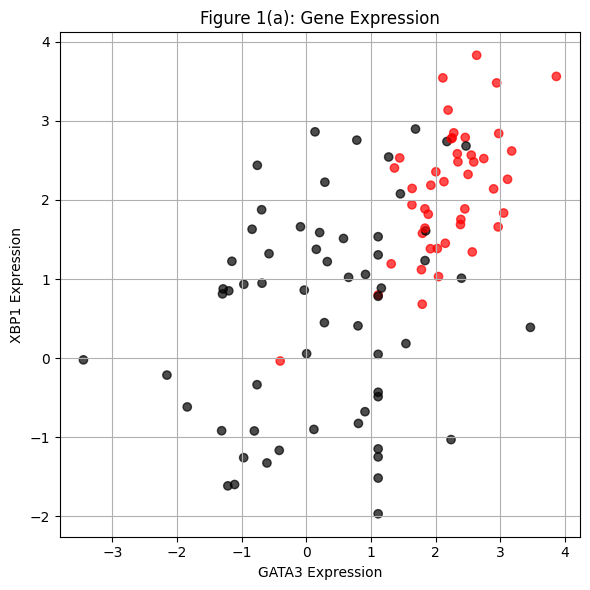

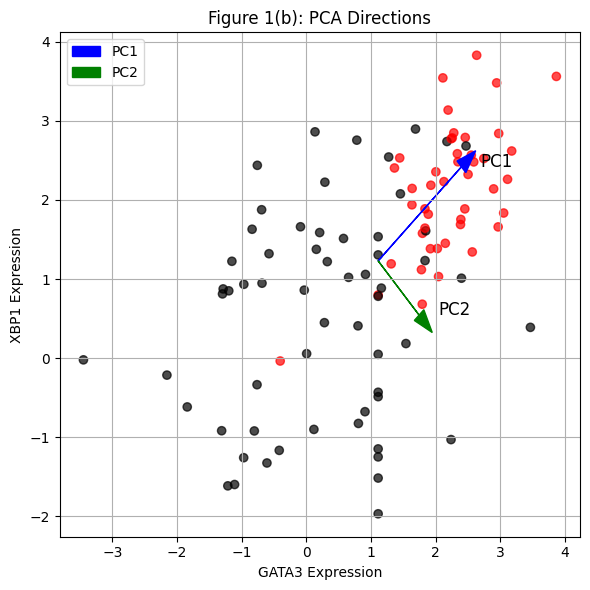

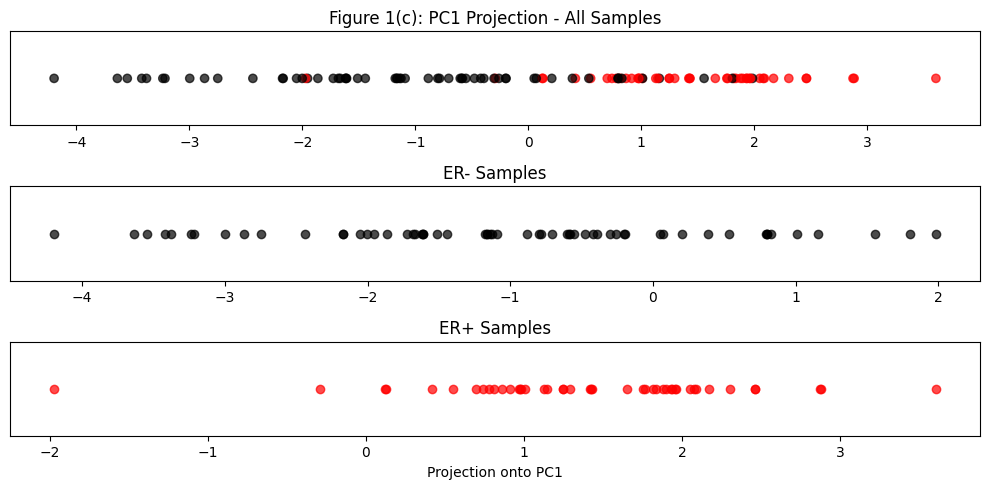

Variance explained by PC1: 0.7792
Variance explained by PC2: 0.2208


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gzip
from io import StringIO
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# File paths
class_labels_path = '/content/drive/MyDrive/class.tsv'
columns_path = '/content/drive/MyDrive/columns.tsv.gz'
filtered_data_path = '/content/drive/MyDrive/filtered.tsv.gz'

# Load class labels
labels = pd.read_csv(class_labels_path, sep='\t', header=None)[0].values

# Load gene mapping
with gzip.open(columns_path, 'rt') as f:
    lines = [line for line in f if not line.startswith('#')]
gene_mapping = pd.read_csv(StringIO(''.join(lines)), sep='\t')

# Load expression data
with gzip.open(filtered_data_path, 'rt') as f:
    expression_data = pd.read_csv(f, sep='\t', index_col=0)
expression_data.columns = expression_data.columns.astype(str).str.strip()

# Extract gene IDs
xbp1_id = '4404'
gata3_id = str(gene_mapping[gene_mapping['GeneSymbol'] == 'GATA3']['ID'].values[0])

# Extract expression values
xbp1_expression = expression_data[xbp1_id].values
gata3_expression = expression_data[gata3_id].values

# Colors
colors = ['black' if label == 0 else 'red' for label in labels]

# PCA function
def perform_pca(X):
    x_centered = X - np.mean(X, axis=0)
    cov_matrix = np.cov(x_centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    idx = np.argsort(eigenvalues)[::-1]
    return eigenvectors[:, idx], eigenvalues[idx], x_centered

# =======================
# Combine expression data
X = np.column_stack((gata3_expression, xbp1_expression))
eigenvectors, eigenvalues, X_centered = perform_pca(X)
pc1, pc2 = eigenvectors[:, 0], eigenvectors[:, 1]
proj_pc1 = X_centered @ pc1

# Flip PC1 for visual alignment
if np.mean(proj_pc1[labels == 1]) < np.mean(proj_pc1[labels == 0]):
    pc1 = -pc1
    proj_pc1 = -proj_pc1

# ============
# Plot 1a: Gene expression
plt.figure(figsize=(6, 6))
plt.scatter(gata3_expression, xbp1_expression, c=colors, alpha=0.7)
plt.xlabel('GATA3 Expression')
plt.ylabel('XBP1 Expression')
plt.title('Figure 1(a): Gene Expression')
plt.grid(True)
plt.tight_layout()
plt.show()

# ============
# Plot 1b: Expression + PCA Arrows


mean_gata3, mean_xbp1 = np.mean(gata3_expression), np.mean(xbp1_expression)
scale1, scale2 = np.sqrt(eigenvalues[0]), np.sqrt(eigenvalues[1])

plt.figure(figsize=(6, 6))
plt.scatter(gata3_expression, xbp1_expression, c=colors, alpha=0.7)
# Add arrows
plt.arrow(mean_gata3, mean_xbp1, pc1[0]*scale1, pc1[1]*scale1,
          head_width=0.2, head_length=0.3, color='blue', label='PC1')
plt.arrow(mean_gata3, mean_xbp1, pc2[0]*scale2, pc2[1]*scale2,
          head_width=0.2, head_length=0.3, color='green', label='PC2')
plt.text(mean_gata3 + pc1[0]*scale1 + 0.3, mean_xbp1 + pc1[1]*scale1, 'PC1', fontsize=12)
plt.text(mean_gata3 + pc2[0]*scale2 + 0.3, mean_xbp1 + pc2[1]*scale2, 'PC2', fontsize=12)
plt.xlabel('GATA3 Expression')
plt.ylabel('XBP1 Expression')
plt.title('Figure 1(b): PCA Directions')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ============
# Plot 1c: PC1 projection



er_pos = proj_pc1[labels == 1]
er_neg = proj_pc1[labels == 0]

plt.figure(figsize=(10, 5))

# All samples
plt.subplot(3, 1, 1)
plt.scatter(proj_pc1, np.zeros_like(proj_pc1), c=colors, alpha=0.7)
plt.title('Figure 1(c): PC1 Projection - All Samples')
plt.yticks([])

# ER- only
plt.subplot(3, 1, 2)
plt.scatter(er_neg, np.zeros_like(er_neg), c='black', alpha=0.7)
plt.title('ER- Samples')
plt.yticks([])

# ER+ only
plt.subplot(3, 1, 3)
plt.scatter(er_pos, np.zeros_like(er_pos), c='red', alpha=0.7)
plt.title('ER+ Samples')
plt.xlabel('Projection onto PC1')
plt.yticks([])

plt.tight_layout()
plt.show()

# Variance Explained
var_exp_pc1 = eigenvalues[0] / sum(eigenvalues)
var_exp_pc2 = eigenvalues[1] / sum(eigenvalues)
print(f"Variance explained by PC1: {var_exp_pc1:.4f}")
print(f"Variance explained by PC2: {var_exp_pc2:.4f}")
